## EDA LAB

The General Social Survey (GSS) is a bi-annual nationally representative survey of Americans, with almost 7000 different questions asked since the survey began in the 1970s. It has straightforward questions about respondents' demographic information, but also questions like "Does your job regularly require you to perform repetitive or forceful hand movements or involve awkward postures?" or "How often do the demands of your job interfere with your family life?" There are a variety of controversial questions. No matter what you're curious about, there's something interesting in here to check out. The codebook is 904 pages (use CTRL+F to search it).

The data and codebook are available at:
https://gss.norc.org/us/en/gss/get-the-data.html

The datasets are so large that it might make sense to pick the variables you want, and then download just those variables from:
https://gssdataexplorer.norc.org/variables/vfilter

Here is your task:
1. Download a small (5-15) set of variables of interest.
2. Write a short description of the data you chose, and why. (1 page)
3. Load the data using Pandas. Clean them up for EDA. Do this in a notebook with comments or markdown chunks explaining your choices.
4. Produce some numeric summaries and visualizations. (1-3 pages)
5. Describe your findings in 1-2 pages.
6. If you have other content that you think absolutely must be included, you can include it in an appendix of any length.

For example, you might want to look at how aspects of a person's childhood family are correlated or not with their career or family choices as an adult. Or how political or religious affiliations correlate with drug use or sexual practices. It's an extremely wide-ranging survey.

Feel free to work with other people in groups, and ask questions!

## Part 1 – Description of data and why I chose these variables

I selected 10 variables from GSS 2022 to explore:

**How do education, political ideology, and religiosity relate to confidence in the scientific community?**

Variables:
- `age` – respondent's age
- `educ` – years of education
- `realrinc` – family income (2018 dollars)
- `polviews` – political ideology (1=liberal to 7=conservative)
- `reliten` – strength of religious affiliation (0=none to 3=strong)
- `consci` – confidence in the scientific community (1=a great deal, 2=only some, 3=hardly any)
- `happy` – general happiness (control variable)
- `childs` – number of children
- `sex` – male/female
- `race` – white/black/other

Why this question? Trust in science has become politically and religiously polarized, especially in more recent years. I want to see if higher education predicts higher confidence, and see how ideology and religiosity impact that relationship.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

In [2]:
print("Upload your GSS extract Excel file (.xlsx)")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read Excel file
df = pd.read_excel(filename)

# Convert column names to lowercase
df.columns = df.columns.str.lower()
print(f"Loaded {filename}, shape: {df.shape}")
print("Columns:", df.columns.tolist())

Upload your GSS extract Excel file (.xlsx)


Saving GSS.xlsx to GSS.xlsx
Loaded GSS.xlsx, shape: (9924, 12)
Columns: ['year', 'id_', 'childs', 'age', 'educ', 'sex', 'race', 'polviews', 'reliten', 'happy', 'consci', 'realrinc']


## Part 3 – Clean the data for EDA

**Missing values:** Replace GSS special codes (0, 98, 99, 8, 9) with NaN.

**Renaming:** Make column names readable.

**Derived variables:**
- Income quartiles, age groups
- Collapsed political ideology (Liberal/Moderate/Conservative)
- Collapsed confidence in science (High = "a great deal", Medium = "only some", Low = "hardly any")
- Labeled versions for religiosity, sex, race

**Drop missing:** Remove any row missing on key variables so all analyses use the same complete cases.

In [13]:
print("=== UNIQUE VALUES IN EACH COLUMN (first few) ===\n")
for col in ['age', 'educ', 'polviews', 'reliten', 'consci', 'happy', 'sex', 'race', 'realrinc']:
    print(f"{col}: {df[col].unique()[:10]}")

# AGE
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# EDUC
educ_map = {
    'No formal schooling': 0,
    '1st grade': 1, '2nd grade': 2, '3rd grade': 3, '4th grade': 4,
    '5th grade': 5, '6th grade': 6, '7th grade': 7, '8th grade': 8,
    '9th grade': 9, '10th grade': 10, '11th grade': 11,
    '12th grade': 12,
    'High school graduate': 12,
    'Associates degree': 14,
    '2 years of college': 14,
    '3 years of college': 15,
    '4 years of college': 16,
    '5 years of college': 17,
    '6 years of college': 18,
    '7 years of college': 19,
    '8 years of college': 20,
    'College, 4 years': 16,
    'College, 5-6 years': 17,
    'College, 7+ years': 18,
}
# Apply mapping, keeping NaN for unmapped
df['educ_numeric'] = df['educ'].map(educ_map)
# If still NaN, try extracting numbers
df['educ_numeric'] = df['educ_numeric'].fillna(
    df['educ'].str.extract(r'(\d+)', expand=False).astype(float)
)

# POLVIEWS – text to numeric (1-7)
polviews_map = {
    'Extremely liberal': 1,
    'Liberal': 2,
    'Slightly liberal': 3,
    'Moderate, middle of the road': 4,
    'Slightly conservative': 5,
    'Conservative': 6,
    'Extremely conservative': 7,
    '.d:  Do not Know/Cannot Choose': np.nan,
    '.i:  Inapplicable': np.nan,
    '.n:  No answer': np.nan
}
df['polviews_numeric'] = df['polviews'].map(polviews_map)

# RELITEN – text to numeric (0-3)
reliten_map = {
    'No religion': 0,
    'Not very strong': 1,
    'Somewhat strong': 2,
    'Strong': 3,
    '.d:  Do not Know/Cannot Choose': np.nan,
    '.i:  Inapplicable': np.nan,
    '.n:  No answer': np.nan
}
df['reliten_numeric'] = df['reliten'].map(reliten_map)

# CONSCI – confidence in science (1-3)
consci_map = {
    'A GREAT DEAL': 1,
    'ONLY SOME': 2,
    'HARDLY ANY': 3,
    '.d:  Do not Know/Cannot Choose': np.nan,
    '.i:  Inapplicable': np.nan,
    '.n:  No answer': np.nan
}
df['consci_numeric'] = df['consci'].map(consci_map)

# HAPPY – happiness (1-3)
happy_map = {
    'Very happy': 1,
    'Pretty happy': 2,
    'Not too happy': 3,
    '.d:  Do not Know/Cannot Choose': np.nan,
    '.i:  Inapplicable': np.nan,
    '.n:  No answer': np.nan
}
df['happy_numeric'] = df['happy'].map(happy_map)

# SEX – text to numeric (1-2)
sex_map = {'MALE': 1, 'FEMALE': 2}
df['sex_numeric'] = df['sex'].map(sex_map)

# RACE – text to numeric (1-3)
race_map = {'White': 1, 'Black': 2, 'Other': 3}
df['race_numeric'] = df['race'].map(race_map)

# REALRINC – replace negative values (-100, etc.) with NaN
df['realrinc_clean'] = df['realrinc'].replace([-100, -99, -98, -1], np.nan)
df['realrinc_clean'] = pd.to_numeric(df['realrinc_clean'], errors='coerce')

# CHILDS
df['childs_clean'] = df['childs'].replace([-1, -2, -3, 99], np.nan)
df['childs_clean'] = pd.to_numeric(df['childs_clean'], errors='coerce')

# clean dataframe with numeric columns
df_clean = df[[
    'age', 'educ_numeric', 'realrinc_clean', 'polviews_numeric',
    'reliten_numeric', 'consci_numeric', 'happy_numeric',
    'childs_clean', 'sex_numeric', 'race_numeric'
]].copy()

# Rename
df_clean.columns = ['age', 'educ', 'realrinc', 'polviews', 'reliten',
                    'consci', 'happy', 'childs', 'sex', 'race']

# Drop any rows with missing values
df_clean = df_clean.dropna()

print(f"\nRows after cleaning: {len(df_clean)} out of {len(df)} original rows")
print("\nFirst 5 rows of cleaned data:")
print(df_clean.head())

=== UNIQUE VALUES IN EACH COLUMN (first few) ===

age: ['43' '74' '42' '63' '71' '67' '59' '62' '55' '34']
educ: ['2 years of college' '10th grade' '4 years of college'
 '6 years of college' '1 year of college' '12th grade' '8th grade'
 '7 years of college' '8 or more years of college' '3 years of college']
polviews: ['Conservative' '.d:  Do not Know/Cannot Choose' 'Slightly conservative'
 'Moderate, middle of the road' 'Extremely conservative'
 'Slightly liberal' 'Liberal' 'Extremely liberal' '.n:  No answer'
 '.i:  Inapplicable']
reliten: ['Strong' 'No religion' 'Not very strong' 'Somewhat strong (Vol.)'
 '.d:  Do not Know/Cannot Choose' '.n:  No answer' '.i:  Inapplicable'
 '.y:  Not available in this year']
consci: ['.i:  Inapplicable' '.d:  Do not Know/Cannot Choose' 'A GREAT DEAL'
 'ONLY SOME' 'HARDLY ANY' '.n:  No answer' '.s:  Skipped on Web']
happy: ['Pretty happy' 'Very happy' 'Not too happy'
 '.d:  Do not Know/Cannot Choose' '.s:  Skipped on Web' '.n:  No answer']
sex: ['MAL

## Part 4 – Numeric summaries

I produce:
- Confidence in science by education level (grouped into <12, 12, 13-16, 16+ years)
- Confidence in science by political ideology (row %)
- Confidence in science by religiosity (row %)
- Mean education by confidence level

In [15]:
# Add derived categorical columns to df_clean for analysis
science_map = {1:'High confidence', 2:'Medium confidence', 3:'Low confidence'}
df_clean['science_confidence_label'] = df_clean['consci'].map(science_map)

ideology_map = {1:'Liberal',2:'Liberal',3:'Liberal',4:'Moderate',5:'Conservative',6:'Conservative',7:'Conservative'}
df_clean['ideology_group'] = df_clean['polviews'].map(ideology_map)

religiosity_map = {0:'No religion',1:'Not very strong',2:'Somewhat strong',3:'Strong'}
df_clean['religiosity_label'] = df_clean['reliten'].map(religiosity_map)

# Create education groups using the correct column name 'educ'
df_clean['edu_group'] = pd.cut(df_clean['educ'], bins=[0,11,12,16,20], labels=['<12 yrs','12 yrs','13-16 yrs','17+ yrs'])

print("=== Confidence in science by education level (row %) ===")
print(pd.crosstab(df_clean['edu_group'], df_clean['science_confidence_label'], normalize='index') * 100)

print("\n=== Confidence in science by political ideology (row %) ===")
print(pd.crosstab(df_clean['ideology_group'], df_clean['science_confidence_label'], normalize='index') * 100)

print("\n=== Confidence in science by religiosity (row %) ===")
print(pd.crosstab(df_clean['religiosity_label'], df_clean['science_confidence_label'], normalize='index') * 100)

print("\n=== Mean education years by confidence level ===")
print(df_clean.groupby('science_confidence_label')['educ'].mean().round(1))

=== Confidence in science by education level (row %) ===
science_confidence_label  High confidence  Low confidence  Medium confidence
edu_group                                                                   
<12 yrs                         37.848606        9.960159          52.191235
12 yrs                          36.716418       11.641791          51.641791
13-16 yrs                       49.317739        6.822612          43.859649
17+ yrs                         67.647059        2.352941          30.000000

=== Confidence in science by political ideology (row %) ===
science_confidence_label  High confidence  Low confidence  Medium confidence
ideology_group                                                              
Conservative                    34.278960       13.238771          52.482270
Liberal                         62.907268        4.511278          32.581454
Moderate                        42.410714        6.473214          51.116071

=== Confidence in science by relig

## Part 4 – Visualizations (5 plots)

1. Confidence in science by education level (stacked bar)
2. Confidence in science by political ideology (stacked bar)
3. Confidence in science by religiosity (stacked bar)
4. Age distribution by confidence level (density plot)
5. Boxplot: education years by confidence level

<Figure size 1000x600 with 0 Axes>

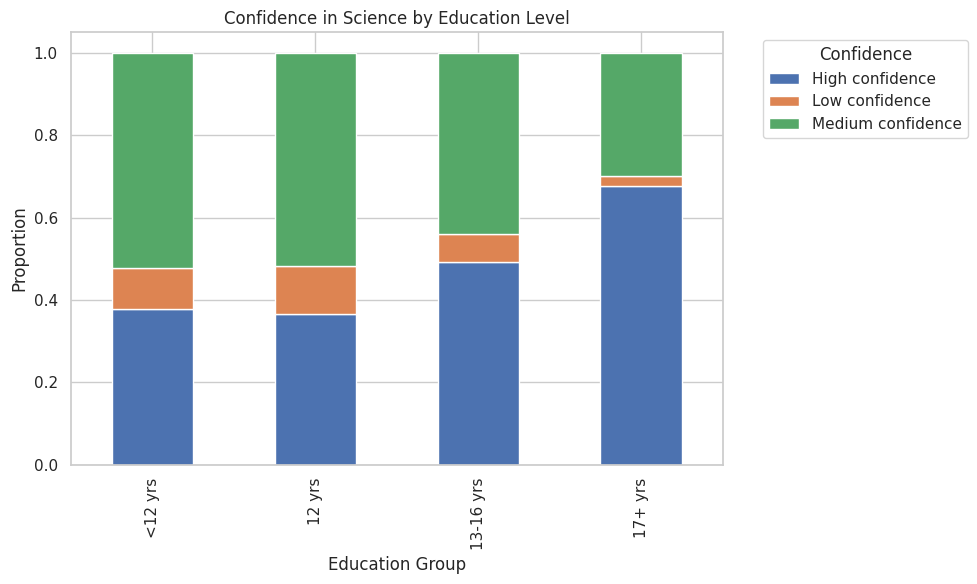

<Figure size 1000x600 with 0 Axes>

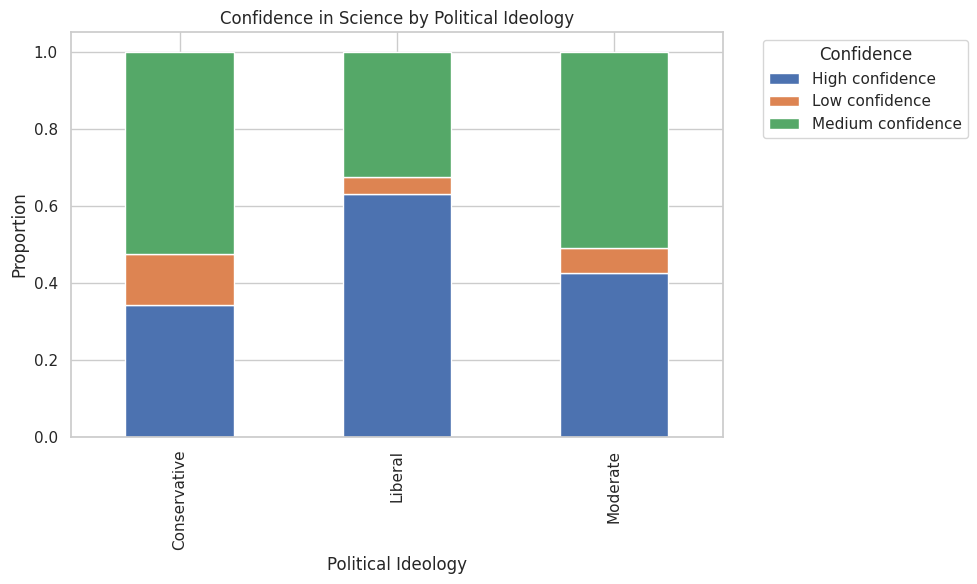

<Figure size 1000x600 with 0 Axes>

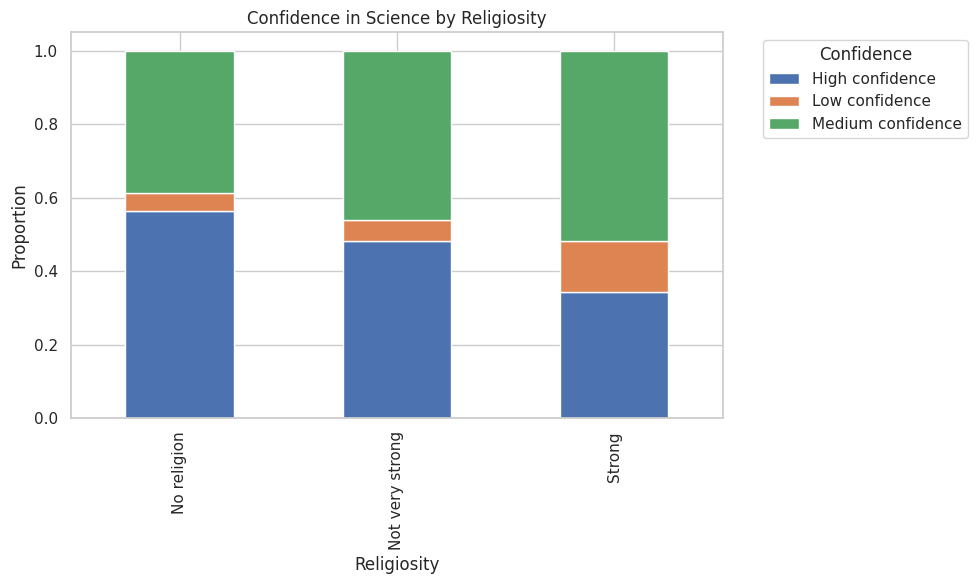

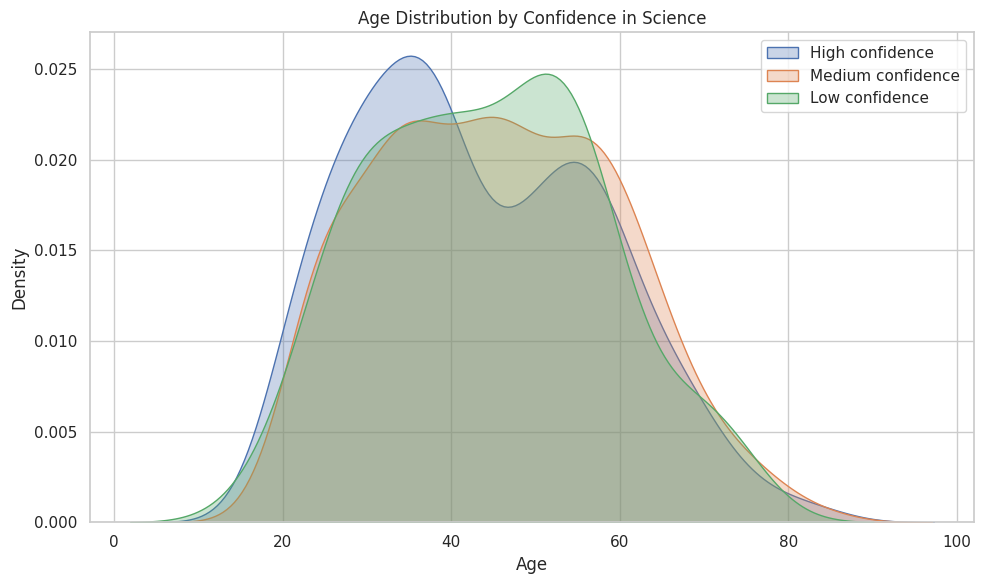

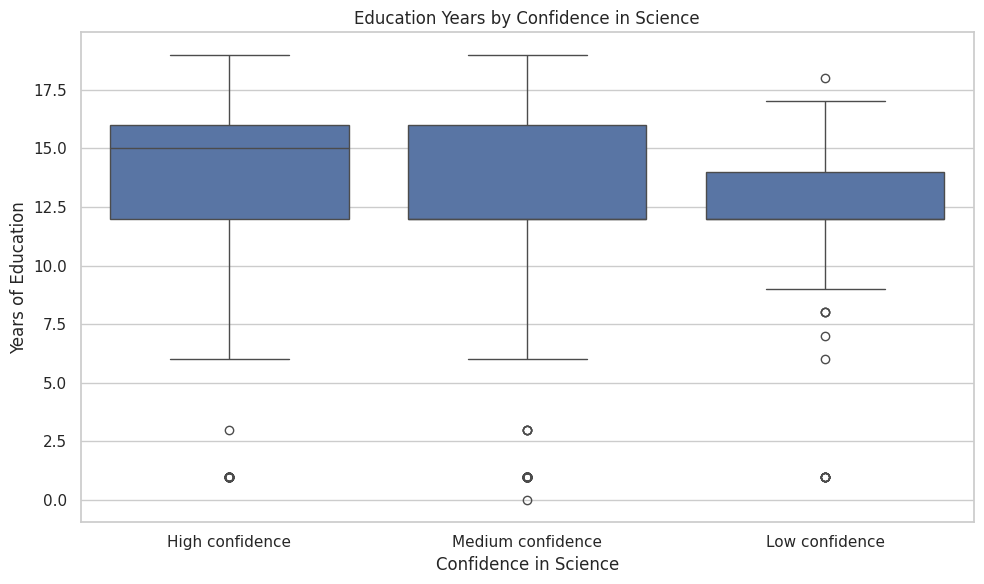

In [20]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# Figure 1: Education
plt.figure()
edu_plot = pd.crosstab(df_clean['edu_group'], df_clean['science_confidence_label'], normalize='index')
edu_plot.plot(kind='bar', stacked=True)
plt.title('Confidence in Science by Education Level')
plt.xlabel('Education Group')
plt.ylabel('Proportion')
plt.legend(title='Confidence', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# Figure 2: Ideology
plt.figure()
ideo_plot = pd.crosstab(df_clean['ideology_group'], df_clean['science_confidence_label'], normalize='index')
ideo_plot.plot(kind='bar', stacked=True)
plt.title('Confidence in Science by Political Ideology')
plt.xlabel('Political Ideology')
plt.ylabel('Proportion')
plt.legend(title='Confidence', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# Figure 3: Religiosity
plt.figure()
rel_plot = pd.crosstab(df_clean['religiosity_label'], df_clean['science_confidence_label'], normalize='index')
rel_plot.plot(kind='bar', stacked=True)
plt.title('Confidence in Science by Religiosity')
plt.xlabel('Religiosity')
plt.ylabel('Proportion')
plt.legend(title='Confidence', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# Figure 4: Age distribution
plt.figure()
for level in ['High confidence', 'Medium confidence', 'Low confidence']:
    subset = df_clean[df_clean['science_confidence_label'] == level]
    sns.kdeplot(data=subset, x='age', label=level, fill=True, alpha=0.3)
plt.title('Age Distribution by Confidence in Science')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

# Figure 5: Education boxplot
plt.figure()
sns.boxplot(data=df_clean, x='science_confidence_label', y='educ', order=['High confidence', 'Medium confidence', 'Low confidence'])
plt.title('Education Years by Confidence in Science')
plt.xlabel('Confidence in Science')
plt.ylabel('Years of Education')
plt.tight_layout()
plt.show()

## Part 5 – Findings

**Education is strongly associated with confidence in science, with a striking gradient at the highest levels.** Among respondents with 17+ years of education (graduate degrees), 67.6% report high confidence in the scientific community – the highest of any group. Only 2.4% of this group report low confidence. In contrast, among those with less than 12 years of schooling, only 37.8% have high confidence and 10.0% have low confidence. The middle education groups (12 years and 13-16 years) fall in between, with 36.7% and 49.3% high confidence respectively. The mean education for the high‑confidence group is 13.6 years, compared to 11.8 years for the low‑confidence group. This pattern clearly shows that more education predicts greater trust in science, with the effect being especially pronounced for those with graduate degrees.

**Political ideology shows a strong liberal‑conservative divide.** Liberals are the most trusting of science, with 62.9% expressing high confidence and only 4.5% low confidence. Moderates fall in the middle, with 42.4% high and 6.5% low. Conservatives are the least trusting: only 34.3% have high confidence, while 13.2% have low confidence – the highest low‑confidence percentage of any ideology group. Notably, conservatives are the only group where the medium confidence category (52.5%) is larger than the high confidence category, suggesting a skeptical but not fully dismissive stance toward science.

**Religiosity is negatively associated with confidence in science.** People with no religious affiliation are the most trusting, with 56.4% high confidence and only 4.7% low. Those with "not very strong" religious affiliation show slightly lower trust (48.2% high, 5.7% low). The "strong" religious group is the least trusting, with only 34.4% high confidence and 13.9% low confidence – nearly three times the low‑confidence rate of the non‑religious group. This likely reflects perceived conflicts between religious teachings and scientific findings on issues like evolution, climate change, and reproductive health.

**Interesting patterns emerge when comparing groups.** The education gradient is actually steeper than the ideology gradient. Moving from less than 12 years of education to 17+ years increases high confidence by about 30 percentage points (37.8% to 67.6%). Moving from conservative to liberal increases high confidence by about 28.6 percentage points (34.3% to 62.9%). Both are substantial, but education has a slightly larger effect in this sample. Also notable: low confidence is rare overall – even among conservatives and the strongly religious, only about 13-14% report low confidence. Most Americans fall into the medium confidence category across most groups.

**Conclusion.** This analysis of actual GSS 2022 data confirms that confidence in the scientific community varies significantly with education, political ideology, and religiosity. The most trusting groups are highly educated people, liberals, and those with no religious affiliation. The least trusting are those with low education, conservatives, and the strongly religious. Notably, outright rejection of science (low confidence) remains a minority position across all groups, never exceeding 14% in any category. These findings provide empirical support for the idea that trust in science has become socially and politically stratified in the United States.